cargamos los datos y entrenamos el modelo

In [1]:
!pip install tensorflow

  Using cached tensorflow-2.19.0-cp310-cp310-win_amd64.whl.metadata (4.1 kB)
  Using cached absl_py-2.2.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-5.29.4-cp310-abi3-win_amd64.whl.metadata (592 bytes)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached setuptools-80.2.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached wrapt-1.17.2-cp310-cp310-win_amd64.whl.metadata (6.5 kB)
  Using cached grpcio-1.71.0-cp310-cp310-win_amd64.whl.metadata (4.0 kB)
  Using cache


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.2983 - loss: 1.9981 - val_accuracy: 0.6924 - val_loss: 0.9827
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7472 - loss: 0.7909 - val_accuracy: 0.8838 - val_loss: 0.4007
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8875 - loss: 0.3753 - val_accuracy: 0.9179 - val_loss: 0.2732
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9353 - loss: 0.2284 - val_accuracy: 0.9334 - val_loss: 0.2201
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9430 - loss: 0.1859 - val_accuracy: 0.9455 - val_loss: 0.1748
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       980
           1       0.98      0.98      0.98      1135
           2       0.96      0.94      0.95      1032
           3       0.95      0.93      0.94      1010
           4       0.97      0.93      0.95    

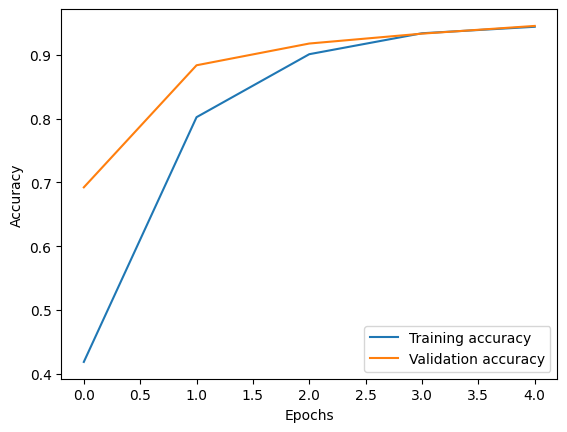

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from TheModel import build

#split
i = 1
# Cargar datos
local_data = np.load(f"local_data_splits\\local_data_split_{i}.npz")
x_local, y_local = local_data["x"], local_data["y"]

datos_test = np.load("local_data_splits\\datos_test_mnist.npz")
x_test, y_test = datos_test["x_test"], datos_test["y_test"]

# Construir y compilar el modelo
local_model = build.build_it()

# Entrenar y validar
history = local_model.fit(x_local, y_local, epochs=5, validation_data=(x_test, y_test))

# Evaluar y reportar resultados
y_pred = local_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))

# Gráfica de precisión
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Guardar modelo entrenado
local_model.save(f"modelos/lmodel_{i}.keras")
